In [1]:
import torch
import pandas as pd
import numpy as np
import torchvision.transforms as Tr
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import napari
from tkinter import filedialog as fd
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import nibabel as nib
import matplotlib as mpl
from skimage.exposure import match_histograms
from nilearn import image
from nilearn import plotting
from scipy.ndimage import gaussian_filter
import math
import matplotlib.patches as patches

In [14]:
def mask(seg, val):
    #To extract individual tissue from segmentation nib file
    binary_mask = np.where(seg == val, 1, 0) # Integer Mask
    return binary_mask

#dataset 1
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain.nii.gz")
seg = nib.load(seg_loc).get_fdata()
"""

#dataset 2
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
"""


#IXI sample 102
'''
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/Data/ixi/T1/102/hf/fast_pveseg.nii.gz"
csf_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_0.nii.gz")
gm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_1.nii.gz")
wm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_2.nii.gz")
img_nib = nib.load("./Data/ixi/T1/102/hf/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
'''

# Validation Data - sub_0011


folder = './Data/validation_data/sub_0015/ulf' 
seg_loc = folder + "/fast_seg.nii.gz"
csf_nib = nib.load(folder + "/fast_pve_0.nii.gz")
gm_nib = nib.load(folder + "/fast_pve_1.nii.gz")
wm_nib = nib.load(folder + "/fast_pve_2.nii.gz")
img_nib = nib.load(folder + "/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
noise = nib.load(folder + "/raw.nii.gz")




#Extracting tissues
csf_masked = mask(seg,1)
gm_masked = mask(seg,2)
wm_masked = mask(seg,3)

csf = csf_masked  * img_nib.get_fdata() #* csf_nib.get_fdata()
gm = gm_masked  * img_nib.get_fdata() #* gm_nib.get_fdata()
wm = wm_masked  * img_nib.get_fdata() #* wm_nib.get_fdata()
hf = hf_img = csf + gm + wm

In [ ]:
csf.shape

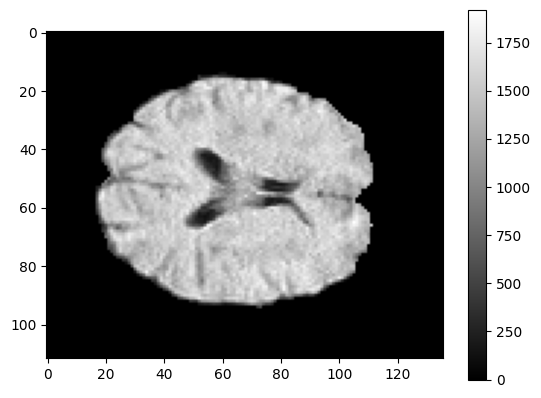

In [15]:
%matplotlib inline
slice_num = 24
plt.imshow(img_nib.get_fdata()[:,:,slice_num],cmap='gray')
plt.colorbar()
plt.show()

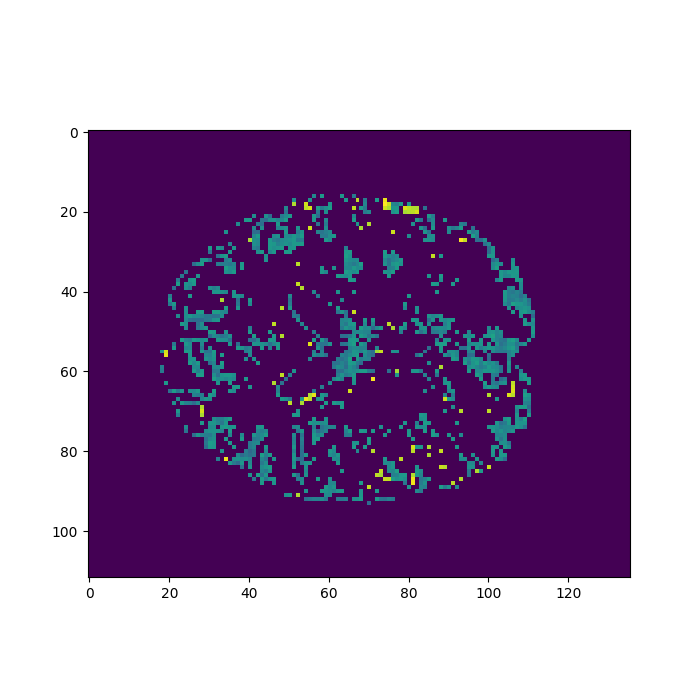

In [23]:
%matplotlib ipympl
# %matplotlib inline

import matplotlib.cbook as cbook
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from mpl_interactions import image_segmenter


im = Image.fromarray((gm*img_nib.get_fdata())[:,:,slice_num])
segmenter = image_segmenter(im, mask_colors="red", mask_alpha=0.99, figsize=(7, 7))
display(segmenter,colormaps='gray',colorbar=segmenter)



In [ ]:
#dataset = 1 #csf (119,82) (128,82) -> (119,85) (128,85) #gm (123, 77) (126, 79) -> (133,70) (135, 74)
#dataset = 2 #wm(135,106) (142,106) -> (135,103) (142, 103) #gm (43, 50) (47,50) -> (43, 46) (47, 46), #csf (64, 101) (83,101) -> (64,98) (83,98)

In [33]:
# csf_x, csf_y, csf_w, csf_h = 54, 54, 3, 2
# gm_x, gm_y, gm_w, gm_h = 61, 87, 4, 2
# wm_x, wm_y, wm_w, wm_h = 41, 74, 4, 4


wm_x, wm_y, wm_w, wm_h = (96, 38, 4, 4)
gm_x, gm_y, gm_w, gm_h = (102, 52, 2, 3)
csf_x, csf_y, csf_w, csf_h = (54, 43, 5, 3)
# bg_x, bg_y, bg_w, bg_h = (9, 90, 5, 5)

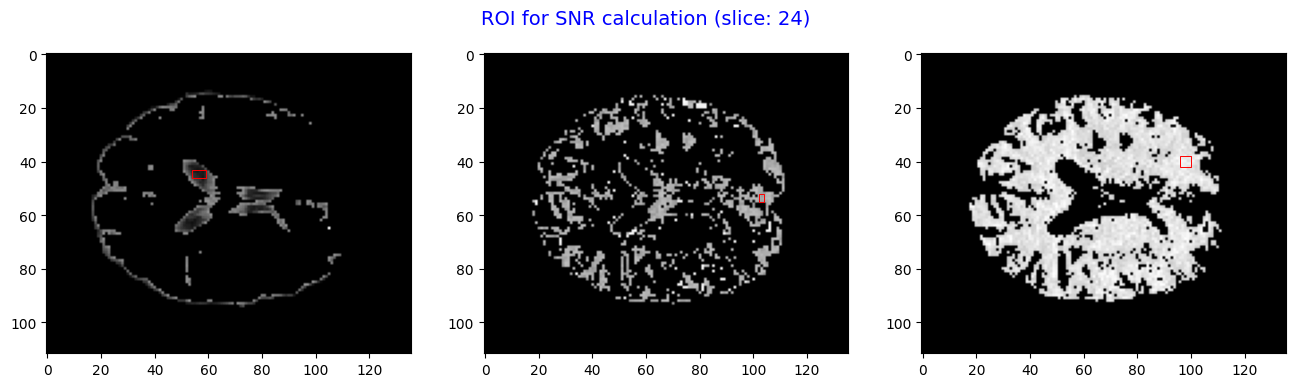

In [34]:
%matplotlib inline
# %matplotlib ipympl

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
im1 = axs[0].imshow((csf)[:,:,slice_num],cmap='gray')# ,vmax = 1000)
im2 = axs[1].imshow((gm)[:,:,slice_num],cmap='gray')#,vmax = 800)
im3 = axs[2].imshow((wm)[:,:,slice_num],cmap='gray')#,vmax = 600)


# rect3 = patches.Rectangle((55, 69), 5, 3, linewidth=1, edgecolor='r', facecolor='none') #ms 
rect0 = patches.Rectangle((csf_x, csf_y), csf_w, csf_h, linewidth=0.7, edgecolor='r', facecolor='none') #csf 
rect1 = patches.Rectangle((gm_x, gm_y), gm_w, gm_h, linewidth=0.7, edgecolor='r', facecolor='none') #gm 
rect2 = patches.Rectangle((wm_x, wm_y), wm_w, wm_h, linewidth=0.7, edgecolor='r', facecolor='none') #wm

axs[0].add_patch(rect0)
axs[1].add_patch(rect1)
axs[2].add_patch(rect2)
# axs[3].add_patch(rect3)



fig.suptitle('ROI for SNR calculation'+ ' (slice: ' + str(slice_num) + ')', fontsize=14,color='blue')
plt.show()

In [ ]:
#dataset = 1
# csf[82:86,119:128,95]
# gm[76:80, 123:128,95]
# wm[99:109,145:155,95]
# print(wm[99:109,145:155,95].mean(), gm[76:80, 123:128,95].mean(), csf[82:86,119:128,95].mean())

#dataset = 2
# print((wm)[105:110, 132:142, 95].mean(), (gm)[45:48,43:48,95].mean(), (csf)[96:101,70:80,95].mean())

Check if there are any pixels where signal intensity = 0

In [37]:
#val data
print(wm[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num])
print(gm[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num])
print(csf[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num])

# print(csf[104:114, 125:133, slice_num])
print("Mean signals of csf: ", csf[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num].mean(), "gm: ", gm[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num].mean(), "wm: ", wm[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num].mean())



[[1601.43200684 1591.50756836 1621.28308105 1474.3560791 ]
 [1675.1595459  1607.88928223 1576.83740234 1599.36157227]
 [1704.51062012 1697.42248535 1666.99951172 1523.20568848]
 [1695.04370117 1653.87145996 1606.77966309 1653.484375  ]]
[[1248.43652344 1184.22973633]
 [1338.42211914 1142.09338379]
 [1252.40197754 1217.74194336]]
[[240.85470581 180.51538086 150.41087341 176.53157043 209.12376404]
 [327.41726685 210.33766174 170.8104248  231.49513245 172.19445801]
 [402.91522217 333.65231323 251.15846252 214.14620972 194.70706177]]
Mean signals of csf:  231.08470052083334 gm:  1230.5542805989583 wm:  1621.8215026855469


In [38]:

#taking mean of only those samples which are 90% probabilistic


wm_roi_pixels = img_nib.get_fdata()[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num][wm_nib.get_fdata()[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num]>0.9]
gm_roi_pixels = img_nib.get_fdata()[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num][gm_nib.get_fdata()[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num]>0.9]
csf_roi_pixels = img_nib.get_fdata()[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num][csf_nib.get_fdata()[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num]>0.9]

print("Mean signals of csf: ",csf_roi_pixels.mean(), "gm: ", gm_roi_pixels.mean(), "wm: ", wm_roi_pixels.mean())


Mean signals of csf:  231.08470052083334 gm:  1255.8725891113281 wm:  1621.8215026855469


Noise
- Loading raw image and computing BG nosie

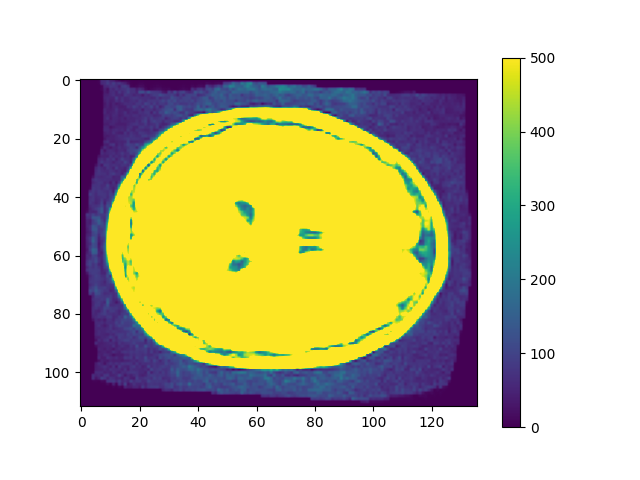

In [46]:
%matplotlib ipympl
# %matplotlib inline


plt.imshow(noise.get_fdata()[:,:,slice_num], vmax = 500)
plt.colorbar()
plt.show()


In [47]:

# bg_x, bg_y, bg_w, bg_h = (8, 88, 10, 10)
bg_x, bg_y, bg_w, bg_h = (14, 8, 8, 8)

std_bg = noise.get_fdata()[:,:,slice_num][bg_y:bg_y+bg_h,bg_x:bg_x+bg_w, ] #region-1 #Validation data
print(std_bg)
std_bg = std_bg.std()
print(std_bg)
# std_bg = noise.get_fdata()[:,:,slice_num][28:42, 20:30, ].std() #region-1 #Validation data
# print(std_bg)
# noise.get_fdata()[:,163,:][50:60,124:138, ].std() #region-2


[[49.98855591 63.98535156 60.98603821 66.98466492 56.98695374 77.98214722
  79.98168945 62.98558044]
 [37.99130249 41.99038696 70.98374939 62.98558044 91.97894287 75.98260498
  58.98649597 90.97917175]
 [47.98901367 38.99107361 44.98970032 53.98764038 66.98466492 58.98649597
  68.98420715 38.99107361]
 [49.98855591 68.98420715 42.99015808 57.98672485 47.98901367 48.98878479
  70.98374939 63.98535156]
 [46.98924255 60.98603821 60.98603821 54.9874115  66.98466492 64.98512268
  54.9874115  65.9848938 ]
 [53.98764038 37.99130249 57.98672485 51.98809814 53.98764038 59.98626709
  59.98626709 69.98397827]
 [50.98832703 48.98878479 49.98855591 55.98718262 52.98786926 70.98374939
  54.9874115  78.98191833]
 [38.99107361 39.99084473 53.98764038 63.98535156 71.98352051 75.98260498
  59.98626709 60.98603821]]
12.208230089881459


In [48]:
rayleigh_correction = 1.53
SNR_WM =  wm_roi_pixels.mean()/(std_bg*rayleigh_correction)
SNR_GM = gm_roi_pixels.mean()/(std_bg*rayleigh_correction)
SNR_CSF = csf_roi_pixels.mean()/(std_bg*rayleigh_correction)

print("SNR_WM:", SNR_WM)
print("SNR_GM:", SNR_GM)
print("SNR_CSF:", SNR_CSF)

SNR_WM: 86.82782403662361
SNR_GM: 67.23593441029858
SNR_CSF: 12.371633796416054


In [49]:
''
lines_to_write = [
    "WM: " + str([wm_x, wm_y, wm_w, wm_h]),
    "GM: " + str([gm_x, gm_y, gm_w, gm_h]),
    "CSF: " + str([csf_x, csf_y, csf_w, csf_h]),
    "BG: " + str([bg_x, bg_y, bg_w, bg_h]),
    "SNR_WM: " + str(SNR_WM),
    "SNR_GM: " + str(SNR_GM),
    "SNR_CSF: " + str(SNR_CSF)
]
file_name = folder + '/snrs.txt'
with open(file_name, "w") as f:  # Open in 'w' (write) mode to overwrite or create the file
    for line in lines_to_write:
        f.write(line + "\n")  # Add a newline character to separate lines

